# EJERCICIO TIPO FINAL 5: ENTRENAMIENTO DE RED NURONAL PARA DETERMINAR SI UN PACIENTE SUFRE DE ANEMIA

## FUENTE : [DATOS ABIERTOS](https://www.datosabiertos.gob.pe/dataset/morbilidad-anemia)

In [1]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 6.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
DATASET_PATH = 'https://github.com/cesarmayta/datasets/raw/refs/heads/main/TB_ANEMIA.csv'
df_anemia = pd.read_csv(DATASET_PATH,sep = ";")
df_anemia.head(10)

,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
0,36178991,6,M,F,NaN,20210524,D509,D,2137
1,38986407,2,A,M,1128.0,20211118,D509,D,10836
2,39002414,1,A,F,1128.0,20210417,D509,D,10836
3,39002414,1,A,F,1128.0,20210413,D509,D,10836
4,39002414,3,A,F,1128.0,20220612,D509,D,10836
5,40663149,3,A,F,1542.0,20230613,D509,D,1030
6,39390036,1,A,F,1128.0,20210118,D509,D,10836
7,39390036,1,A,F,1128.0,20210123,D509,D,10836
8,39390036,1,A,F,1128.0,20210518,D509,D,10836
9,39390036,2,A,F,1128.0,20220116,D509,D,10836


# EDA

In [22]:
df_anemia.shape

(1327924, 9)

In [23]:
df_anemia.dtypes

,0
id_persona,int64
Edad,int64
Tipo_edad,object
Sexo,object
id_ubigeo,float64
Fecha_atencion,int64
Diagnostico,object
Tipo_Dx,object
id_eess,int64


# TRATAMIENTO DE NULOS

In [24]:
df_anemia.isnull().sum().sum()

np.int64(10817)

In [25]:
df_anemia.isnull().sum()

,0
id_persona,0
Edad,0
Tipo_edad,0
Sexo,0
id_ubigeo,10817
Fecha_atencion,0
Diagnostico,0
Tipo_Dx,0
id_eess,0


In [26]:
df_anemia.dropna(subset=['id_ubigeo'],inplace=True)
df_anemia.shape

(1317107, 9)

# TRATAMIENTO DE DUPLICADOS

In [27]:
df_anemia.duplicated().sum()

np.int64(19287)

In [28]:
df_anemia[df_anemia.duplicated()]

,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
16,39347963,1,A,F,1128.0,20210814,D509,D,21206
28,41907576,6,M,F,1209.0,20240316,D509,D,17076
574,39320800,3,A,F,1504.0,20210312,D509,D,87
629,38701922,4,A,M,42.0,20220104,D509,D,5180
660,39320673,4,A,F,42.0,20221029,D509,D,5188
...,...,...,...,...,...,...,...,...,...
1327161,42009830,6,M,M,1453.0,20240507,D509,D,12
1327223,41940907,7,M,M,1000.0,20240613,D509,D,3356
1327377,42037152,6,M,F,1276.0,20240518,D509,D,4404
1327466,42068631,6,M,M,1322.0,20240530,D509,D,5846


In [29]:
df_anemia.drop_duplicates(keep='first',inplace=True)
df_anemia.shape

(1297820, 9)

# ANALIZANDO VARIABLES

## ELIMINAMOS ID_PERSONA

In [30]:
df_anemia.drop(['id_persona'],axis=1,inplace=True)
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
1,2,A,M,1128.0,20211118,D509,D,10836
2,1,A,F,1128.0,20210417,D509,D,10836
3,1,A,F,1128.0,20210413,D509,D,10836
4,3,A,F,1128.0,20220612,D509,D,10836
5,3,A,F,1542.0,20230613,D509,D,1030
6,1,A,F,1128.0,20210118,D509,D,10836
7,1,A,F,1128.0,20210123,D509,D,10836
8,1,A,F,1128.0,20210518,D509,D,10836
9,2,A,F,1128.0,20220116,D509,D,10836
10,3,A,F,1597.0,20210529,D509,D,2177


# CONVERTIMOS DATA  DE EDAD A AÑOS

In [31]:
df_anemia.Tipo_edad.value_counts()

,count
Tipo_edad,
A,920953
M,375857
D,1010


In [32]:
df_anemia['edad_total'] = np.where(
    df_anemia['Tipo_edad'] == 'M', df_anemia['Edad'] / 12,
    np.where(df_anemia['Tipo_edad'] == 'D', df_anemia['Edad'] / 365, df_anemia['Edad'])
)
df_anemia[df_anemia['Tipo_edad']=='D'].head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total
944,1,D,F,1128.0,20210531,D509,D,10836,0.002740
1418,20,D,M,994.0,20210608,D539,D,3364,0.054795
5144,1,D,F,1317.0,20210426,D509,D,5509,0.002740
6928,1,D,M,1484.0,20220407,D509,D,143,0.002740
6987,18,D,M,1458.0,20210702,D509,D,64,0.049315
6991,24,D,M,1473.0,20210706,D509,D,105,0.065753
7157,1,D,F,1322.0,20210811,D509,D,6129,0.002740
7613,6,D,F,1464.0,20210213,D509,D,212,0.016438
7862,1,D,M,1460.0,20210805,D509,D,16,0.002740
7881,1,D,F,1463.0,20210807,D509,D,30,0.002740


# ANALIZAMOS DIAGNOSTICO

In [33]:
df_anemia['cie10'] = np.where(df_anemia['Diagnostico'].str.startswith(('D50','D53','D64')),1,0)

In [34]:
df_anemia.head(3)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,cie10
1,2,A,M,1128.0,20211118,D509,D,10836,2.0,1
2,1,A,F,1128.0,20210417,D509,D,10836,1.0,1
3,1,A,F,1128.0,20210413,D509,D,10836,1.0,1


In [ ]:
df_anemia['Fecha_atencion'] = df_anemia['Fecha_atencion'].astype(str)
df_anemia['Fecha_atencion'] = pd.to_datetime(df_anemia['Fecha_atencion'],format='%Y%m%d')
df_anemia.head(10)

In [40]:
df_anemia['Fecha_atencion'].sort_values(ascending=True)

,Fecha_atencion
373591,2021-01-01
14212,2021-01-01
253667,2021-01-01
310994,2021-01-01
903808,2021-01-01
...,...
1200519,2024-06-30
1227527,2024-06-30
781581,2024-06-30
1278764,2024-06-30


In [44]:
df_anemia_clean = df_anemia[['Fecha_atencion','cie10']].copy()
df_anemia_clean.rename(columns={'Fecha_atencion':'fecha','cie10':'anemia'},inplace=True)
df_anemia_clean

,fecha,anemia
1,2021-11-18,1
2,2021-04-17,1
3,2021-04-13,1
4,2022-06-12,1
5,2023-06-13,1
...,...,...
1327918,2021-08-16,0
1327919,2022-03-08,1
1327920,2022-03-19,0
1327921,2023-04-28,1


In [47]:
df_anemia_clean = df_anemia_clean.sort_values(by='fecha', ascending=True)
df_anemia_clean

,fecha,anemia
373591,2021-01-01,1
14212,2021-01-01,1
253667,2021-01-01,1
310994,2021-01-01,1
903808,2021-01-01,1
...,...,...
1200519,2024-06-30,1
1227527,2024-06-30,1
781581,2024-06-30,1
1278764,2024-06-30,1


In [49]:
df_anemia_clean = df_anemia_clean[df_anemia_clean['anemia'] == 1].sort_values(by='fecha', ascending=True)
df_anemia_clean

,fecha,anemia
373591,2021-01-01,1
12948,2021-01-01,1
318464,2021-01-01,1
330388,2021-01-01,1
477780,2021-01-01,1
...,...,...
1278764,2024-06-30,1
1200519,2024-06-30,1
1227527,2024-06-30,1
781581,2024-06-30,1


In [50]:
df_anemia_series = df_anemia_clean.groupby(['fecha']).size().reset_index(name='nro_casos')
df_anemia_series

,fecha,nro_casos
0,2021-01-01,228
1,2021-01-02,676
2,2021-01-03,190
3,2021-01-04,1398
4,2021-01-05,1231
...,...,...
1272,2024-06-26,413
1273,2024-06-27,317
1274,2024-06-28,203
1275,2024-06-29,60


In [57]:
df_anemia_series['fecha'] = pd.to_datetime(df_anemia_series['fecha'])
df_anemia_series.dtypes

,0
fecha,datetime64[ns]
nro_casos,int64


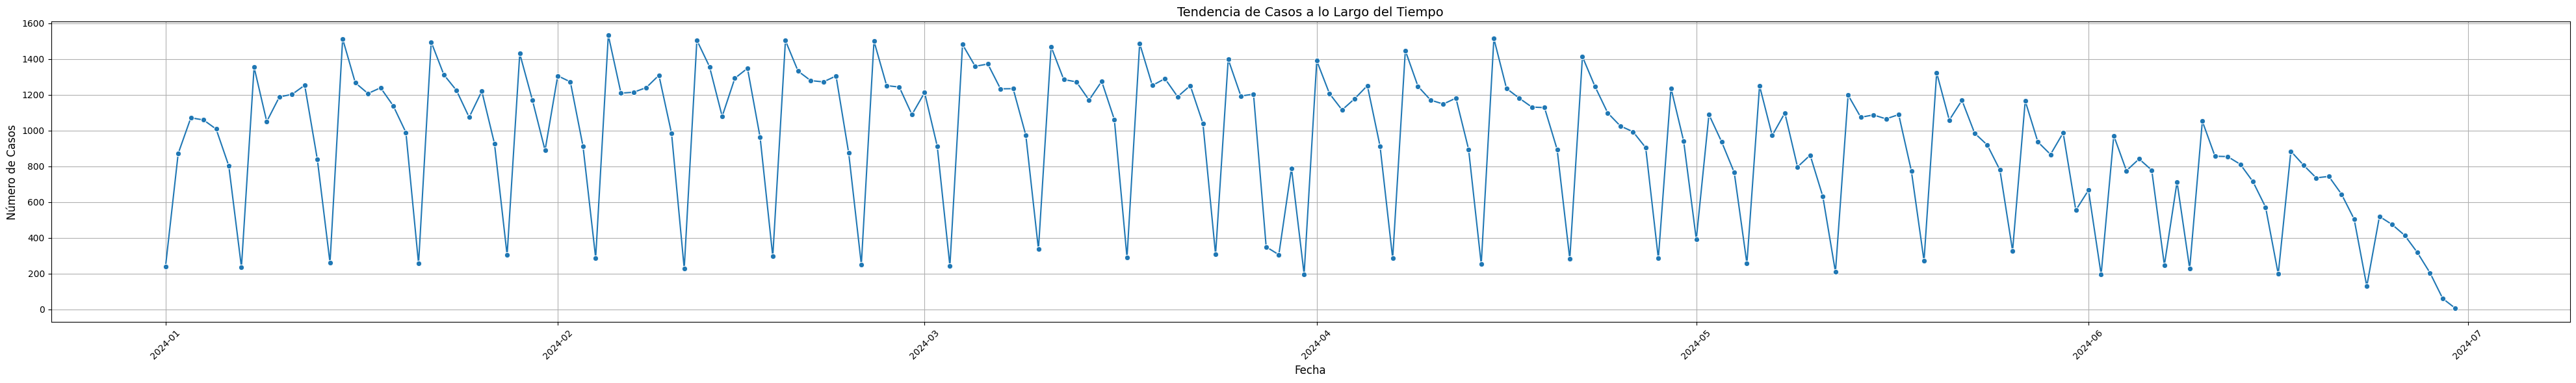

In [64]:
plt.figure(figsize=(50, 6))

# Crear el gráfico de línea
sns.lineplot(data=df_anemia_series[df_anemia_series['fecha'].dt.year == 2024], x='fecha', y='nro_casos', marker='o', linestyle='-')

# Personalizar el gráfico
plt.title('Tendencia de Casos a lo Largo del Tiempo', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje x para mejor legibilidad
plt.grid(True)

# Mostrar el gráfico
plt.show()

# GUARDAMOS EL DATASET

In [65]:
df_anemia_series.to_csv('anemia_series.csv',index=False)

In [66]:
df = pd.read_csv('/content/anemia_series.csv')
df

,fecha,nro_casos
0,2021-01-01,228
1,2021-01-02,676
2,2021-01-03,190
3,2021-01-04,1398
4,2021-01-05,1231
...,...,...
1272,2024-06-26,413
1273,2024-06-27,317
1274,2024-06-28,203
1275,2024-06-29,60


# PREPARACION DE LOS DATOS PARA ENTRENAMIENTO CON REDES NEURONALES

## ESCALAMIENTO DE VARIABLES Y CREAR SECUENCIA PARA X Y Y

In [67]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(df['nro_casos'].values.reshape(-1,1))
data

array([[0.12492997],
       [0.37591036],
       [0.10364146],
       ...,
       [0.11092437],
       [0.03081232],
       [0.        ]])

In [68]:
# Crear secuencias para la serie temporal
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [69]:
seq_length = 30  # Usar 30 dias
X, y = create_sequences(data, seq_length)

## DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [70]:
from sklearn.model_selection import train_test_split

# Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## CREAMOS NUESTRA RED NEURONAL

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
# Construcción del modelo LSTM en TensorFlow
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25, activation="relu"),
    Dense(1)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# ENTRENAMOS LA RED NEURONAL

In [73]:
model.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(X_test, y_test))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.1676 - val_loss: 0.0524
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0501 - val_loss: 0.0523
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0506 - val_loss: 0.0522
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0502 - val_loss: 0.0521
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0521 - val_loss: 0.0541
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0489 - val_loss: 0.0521
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0536 - val_loss: 0.0525
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0503 - val_loss: 0.0524
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0500 - val_loss: 0.0568
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0508 - val_loss: 0.0531
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0551 - val_loss: 0.0549
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

# GRAFICAMOS PREDICCIONES

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


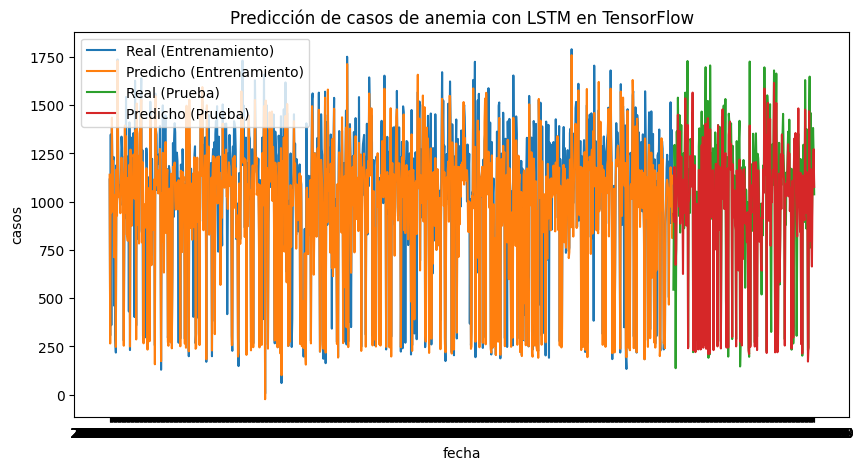

In [74]:
# Realizar predicciones
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
split = int(len(X) * 0.8)
# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(df["fecha"][seq_length:split+seq_length], scaler.inverse_transform(y_train), label="Real (Entrenamiento)")
plt.plot(df["fecha"][seq_length:split+seq_length], scaler.inverse_transform(y_pred_train), label="Predicho (Entrenamiento)")
plt.plot(df["fecha"][split+seq_length:], scaler.inverse_transform(y_test), label="Real (Prueba)")
plt.plot(df["fecha"][split+seq_length:], scaler.inverse_transform(y_pred_test), label="Predicho (Prueba)")
plt.legend()
plt.xlabel("fecha")
plt.ylabel("casos")
plt.title("Predicción de casos de anemia con LSTM en TensorFlow")
plt.show()